In [34]:
import os
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
import random

In [37]:
#   seems useless...
def add_white_noise(audio_path, out_path, percent=0.2, sr=16000):
    src, sr = librosa.load(audio_path, sr=sr)
    random_values = np.random.rand(len(src))
    src = src + percent * random_values
    sf.write(out_path, src, sr)

#   通过准备好的噪音文件读取后给数据加噪音，要求噪音文件的长度至少是数据集中单个的音频
#   长度的两倍
def addNoiseFromWav(audio_path, out_path, noise, percent=0.2, sr=16000):
    audio,_ = librosa.load(audio_path,sr)
    audio_lenth = len(audio)
    noise_lenth = len(noise)
    if audio_lenth*2 > noise_lenth:
        return
    start_point = random.randint(0,noise_lenth-1-audio_lenth)
    for i in range(audio_lenth):
        audio[i] += percent*noise[start_point+i]
    sf.write(out_path,audio,sr)
    

def denoise(audio_path, out_path, threshold, sr=16000):
    src, sr = librosa.load(audio_path, sr=sr)
    audioLenth = len(src)
    count = 0.1*sr
    for i in range(audioLenth):
        #   for volume < threashold for 0.1s, make it zero
        if abs(src[i]) < threshold:
            if count >= 0.1*sr:
                src[i] = 0.
            else:
                count+=1
        else:
            count = 0

    sf.write(out_path,src,sr)




In [39]:
#   paths
RAW_DATA_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav/'
NOISED_DATA_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_noised/'
DENOISED_DATA_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_denoised/'
LABEL_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_labels/'
NOISE_SAMPLE_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/office noise_WAV.wav'

In [ ]:
#   add noise to raw data
#   denoise raw data (Zero operating. in case to label)
noise,_ = librosa.load(NOISE_SAMPLE_PATH, 16000)
for x in os.scandir(RAW_DATA_PATH):
    denoise(os.path.relpath(x), DENOISED_DATA_PATH+os.path.split(os.path.relpath(x))[-1],0.05,16000)
    addNoiseFromWav(os.path.relpath(x),NOISED_DATA_PATH,noise,0.2,16000)

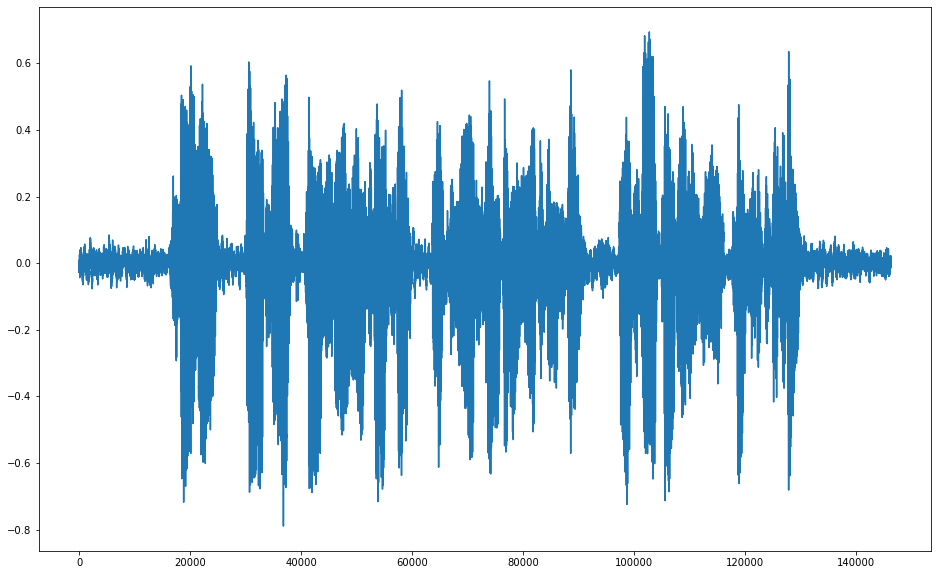

In [48]:
#   unprocess
noised, _ = librosa.load(NOISED_DATA_PATH+'common_voice_zh-CN_18531544_WAV.wav',sr=16000)
plt.figure(figsize=(16,10))
#plt.plot(range(len(raw)),raw)
plt.plot(range(len(noised)),noised)

plt.show()
#   denoised data
#   noised data
#   labeled data
